# importing libraries

In [88]:
import os

from PIL import Image
import cv2
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn import neural_network
import reteleNeuronale.AnnCode
import reteleNeuronale.CnnCode

import importlib
importlib.reload(reteleNeuronale.AnnCode)
importlib.reload(reteleNeuronale.CnnCode)

from reteleNeuronale.AnnCode import AnnCode
from reteleNeuronale.CnnCode import CNNCode

# Sepia Filter Data Base  ( imaginile sunt 128 x 128 px)

In [2]:
def sepia_func(src_image):
    gray = cv2.cvtColor(src_image, cv2.COLOR_BGR2GRAY)
    normalized_gray = np.array(gray, np.float32)/255
    #solid color
    sepia = np.ones(src_image.shape)
    sepia[:,:,0] *= 153 #B
    sepia[:,:,1] *= 204 #G
    sepia[:,:,2] *= 255 #R
    #hadamard
    sepia[:,:,0] *= normalized_gray #B
    sepia[:,:,1] *= normalized_gray #G
    sepia[:,:,2] *= normalized_gray #R
    return np.array(sepia, np.uint8)

In [18]:
base_dir = 'imagesDataBase'
sepia_dir = os.path.join(base_dir, 'sepia')

os.makedirs(sepia_dir, exist_ok=True)

for filename in os.listdir(base_dir):
    file_path = os.path.join(base_dir, filename)
    if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image = cv2.imread(file_path)
        if image is not None:
            
            sepia_image = sepia_func(image)
            
            sepia_path = os.path.join(sepia_dir, "sepia_"+filename)
            cv2.imwrite(sepia_path, sepia_image)

## Train data 

In [4]:
def splitData(inputs, outputs):
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, size=int(0.8*len(inputs)), replace=False)
    testSample = [i for i in indexes if i not in trainSample]
    
    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]
    
    return trainInputs, trainOutputs, testInputs, testOutputs

## Histograme

In [5]:
def histo(outputs):
    bins = range(3)
    plt.hist(outputs,bins ,rwidth=0.8)
    bin_w = (max(bins) - min(bins))/(len(bins)-1)
    plt.xticks(np.arange(min(bins)+bin_w/2, max(bins),bin_w),["Original","Sepia"])
    plt.show()

## normalizare

In [6]:
def flatten(mat):
    x = []
    for line in mat:
        for pixel in line:
            for el in pixel:
                x.append(el)
    return x

In [7]:
def z_normalization(x):
    x = np.array(x)
    return ((x - x.mean()) / x.std()).tolist()

## Data

Number of images:  400


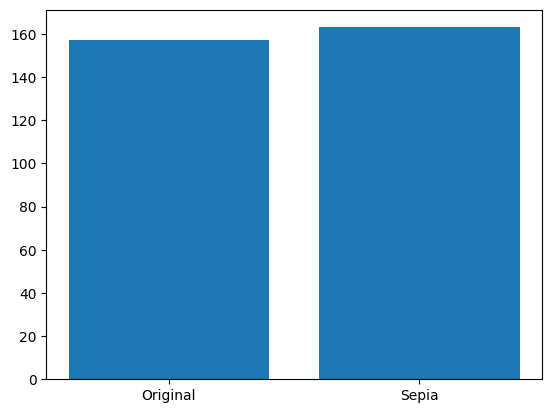

In [25]:
def getData():
    imagini = []
    outputs = 200 * [0] + 200 * [1]
    
    for filename in os.listdir(base_dir):
        file_path = os.path.join(base_dir, filename)
        if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
           image = Image.open(file_path).convert('RGB')
           imagini.append(image)
    
    for filename in os.listdir(sepia_dir):
        file_path = os.path.join(sepia_dir, filename)
        if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image = Image.open(file_path).convert('RGB')
            imagini.append(image)
            
    print("Number of images: ", len(imagini))
            
    TI,TO, VI,VO = splitData(imagini, outputs)
    
    histo(TO)
    
    TIF , VIF = [flatten(np.array(image)) for image in TI], [flatten(np.array(image)) for image in VI]
    
    TIN, VIN = z_normalization(TIF),z_normalization(VIF)
    
    return TIN,VIN,TO,VO
    
TI , VI , TO, VO = getData()

## Eroare

In [9]:
def evalMultiClass(realLabels, computedLabels, labelNames):
    from sklearn.metrics import confusion_matrix

    confMatrix = confusion_matrix(realLabels, computedLabels)
    acc = sum([confMatrix[i][i] for i in range(len(labelNames))]) / len(realLabels)
    precision = {}
    recall = {}
    for i in range(len(labelNames)):
        precision[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[j][i] for j in range(len(labelNames))])
        recall[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[i][j] for j in range(len(labelNames))])
    return acc, precision, recall, confMatrix

## plot

In [10]:
def plotConfusionMatrix(cm, classNames, title):
    from sklearn.metrics import confusion_matrix
    import itertools 

    classes = classNames
    plt.figure()
    plt.imshow(cm, interpolation = 'nearest', cmap = 'Blues')
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=45)
    plt.yticks(tick_marks, classNames)

    text_format = 'd'
    thresh = cm.max() / 2.
    for row, column in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(column, row, format(cm[row, column], text_format),
                horizontalalignment = 'center',
                color = 'white' if cm[row, column] > thresh else 'black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

    plt.show()

## Cu ANN tool

Iteration 1, loss = 3.45076374
Iteration 2, loss = 8.50669440
Iteration 3, loss = 1.34973587
Iteration 4, loss = 0.69116564
Iteration 5, loss = 0.58373597
Iteration 6, loss = 0.87621382
Iteration 7, loss = 0.55649306
Iteration 8, loss = 0.48015763
Iteration 9, loss = 0.43148088
Iteration 10, loss = 0.42184112
Iteration 11, loss = 0.41032838
Iteration 12, loss = 0.38605536
Iteration 13, loss = 0.36109469
Iteration 14, loss = 0.33935697
Iteration 15, loss = 0.33304404
Iteration 16, loss = 0.32818103
Iteration 17, loss = 0.32746501
Iteration 18, loss = 0.32344550
Iteration 19, loss = 0.31939136
Iteration 20, loss = 0.31352056
Iteration 21, loss = 0.31187479
Iteration 22, loss = 0.30870179
Iteration 23, loss = 0.30147312
Iteration 24, loss = 0.29461540
Iteration 25, loss = 0.28918944
Iteration 26, loss = 0.29441783
Iteration 27, loss = 0.28548101
Iteration 28, loss = 0.28544416
Iteration 29, loss = 0.28535832
Iteration 30, loss = 0.28412938
Iteration 31, loss = 0.27984697
Iteration 32, los

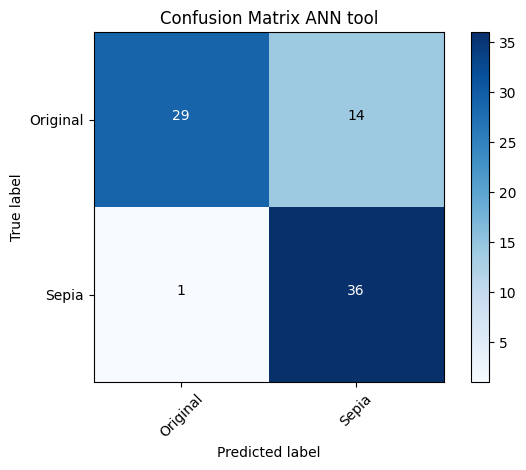

0.8125


In [11]:
trainInputs , trainOutputs, testInputs, testOutputs = TI.copy(), TO.copy(), VI.copy(), VO.copy()

classifer = neural_network.MLPClassifier(hidden_layer_sizes=(5,), activation='relu',max_iter=100,solver='sgd', verbose=10, random_state=1, learning_rate_init=.1)

classifer.fit(trainInputs, trainOutputs)

predictions = classifer.predict(testInputs)
acc , prec ,recall , cm = evalMultiClass(testOutputs, predictions, ["Original", "Sepia"])

plotConfusionMatrix(cm, ["Original", "Sepia"], "ANN tool")
print(acc)


# influenta (hyper)parametrilor:

hidden_layers: numarul de neuroni de pe fiecare layer
    daca sunt prea multi consuma memorie si timpul de antrenare creste , daca sunt putini acuratetea scade

activation: functia de activare pentru neuroni
    de exemplu : relu : relu(x) = max(0,x)
     sau tahn : tahn(x) = (e^x - e^-x)/(e^x + e^-x)

max_iter: numarul de iteratii ale retelei
    daca sunt prea multe poate da overfitting, daca sunt putin accuratetea scade

solver: algoritmul de optimizare pentru actualizarea ponderilor
    adam: algoritm de optimizare bazat pe gradient
    sgd: stochastic gradient descent

random_state: for random generation

verbose: din cat in cat sa se afiseze loss-ul in iteratii

learning_rate:  tipul de invatare , constant sau se schimba learning rate-ul

learning_rate_init: valoarea cu care invata reteau neuronala

# ANN COD PROPRIU   

Training neural network with 3 hidden layers...
Architecture: 49152 -> 124 -> 64 -> 36 -> 1
Epoch 10/100: loss: 0.140156, lr: 0.001000
Epoch 20/100: loss: 0.108832, lr: 0.001000
Epoch 30/100: loss: 0.067780, lr: 0.001000
Epoch 40/100: loss: 0.056692, lr: 0.001000
Epoch 50/100: loss: 0.041039, lr: 0.001000
Epoch 60/100: loss: 0.030652, lr: 0.001000
Epoch 70/100: loss: 0.018938, lr: 0.001000
Epoch 80/100: loss: 0.011978, lr: 0.001000
Epoch 90/100: loss: 0.008025, lr: 0.001000
Epoch 100/100: loss: 0.004315, lr: 0.001000
Training complete. Final loss: 0.004315


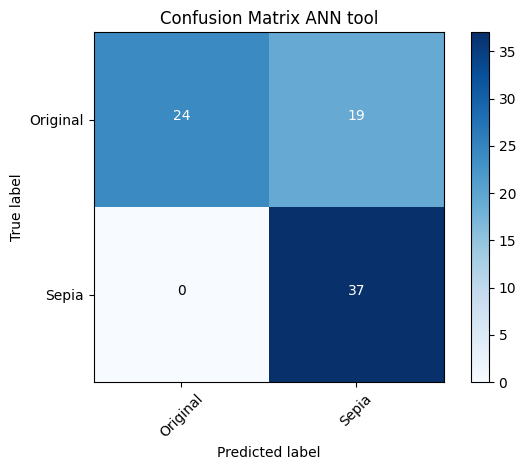

0.7625


In [12]:
trainOutputs, testInputs, testOutputs = TO.copy(), VI.copy(), VO.copy()

trainInputs = np.array(TI)

classifer = AnnCode(hidden_layers=(124,64,36), activation='tanh',max_iter=100,solver='adam', verbose=10, random_state=None, learning_rate_init=.001)

classifer.fit(trainInputs, trainOutputs)

predictions = classifer.predict(testInputs)
predictions_bool = []
for a in predictions:
    predictions_bool.append(np.where(a >= 0.5, 1, 0))

acc , prec ,recall , cm = evalMultiClass(testOutputs, predictions_bool, ["Original", "Sepia"])

plotConfusionMatrix(cm, ["Original", "Sepia"], "ANN tool")
print(acc)

# CNN Cod propriu

## Incarcare imagini CNN

In [80]:
def load_images_forCNN(dir):
    images = []
    for filename in os.listdir(dir):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(dir,filename)
            img = Image.open(img_path).convert('RGB')
            
            #Resize pentru calcule mai rapide
            img = img.resize((64,64))
        
            img_array = np.array(img)
            img_array = img_array.transpose(2,0,1)
            
            #Normalizare imagini min--Max
            img_array = img_array/ 255.0
            
            images.append(img_array)
    
    return np.array(images)

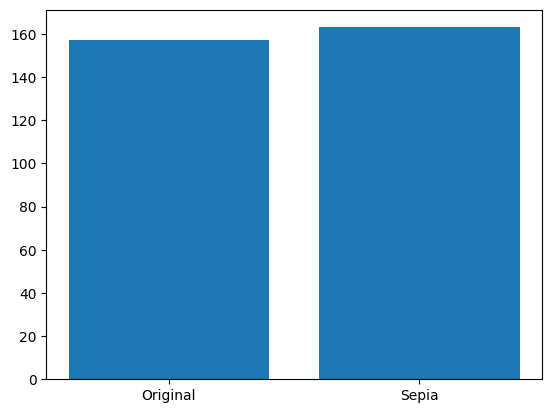

Training CNN with 2 convolutional layers and 1 fully connected layers...
Input shape: (3, 64, 64)
start
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
foward
backward
Epoch 1/50: loss: 0.311779, lr: 0.001000
start
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 


In [96]:
CNNinput1 = load_images_forCNN(base_dir) 
CNNinput2 = load_images_forCNN(sepia_dir)
CNNinput = np.concatenate((CNNinput1, CNNinput2), axis=0)

CNNouput = 200 * [0] + 200 * [1]

#date de testare
TI,TO,VI,VO = splitData(CNNinput,CNNouput)

histo(TO)

classifierCNN = CNNCode(
    filters=[8, 16],
    kernel_sizes=[(5, 5), (5, 5)],  
    strides=[(1, 1), (1, 1)], 
    padding='same',
    activation='relu',  
    pooling='max',  
    pooling_sizes=[(2, 2), (2, 2)], 
    pooling_strides=[(2, 2), (2, 2)], 
    hidden_layers=(60,),  
    max_iter=50,  
    solver='sgd',  
    verbose=1, 
    learning_rate_init=0.001 
)
classifierCNN.fit(np.array(TI), np.array(TO))

0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 


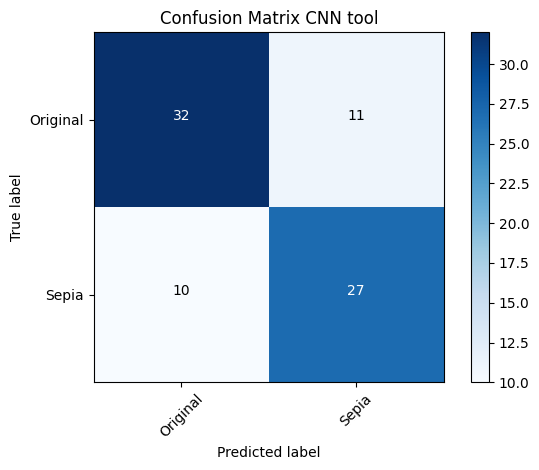

0.7375


In [98]:
predictions = classifierCNN.predict(np.array(VI))

predictions_bool = []
for a in predictions:
    predictions_bool.append(np.where(a >= 0.5, 1, 0))
    
acc , prec ,recall , cm = evalMultiClass(VO, predictions_bool, ["Original", "Sepia"])
plotConfusionMatrix(cm, ["Original", "Sepia"], "CNN tool")
print(acc)

# Save model and read, pentru a nu mai astepta 

In [99]:
classifierCNN.save_model(os.path.join('reteleNeuronale', 'model2.h5'))

0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 
0% | 100% 
10% | 100% 
20% | 100% 
30% | 100% 
40% | 100% 
50% | 100% 
60% | 100% 
70% | 100% 
80% | 100% 
90% | 100% 


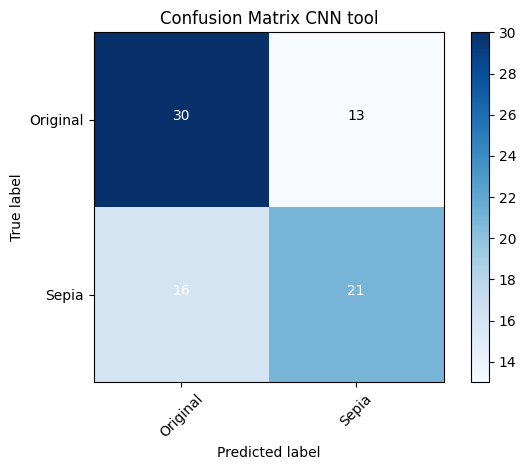

0.6375


In [97]:
new_class = CNNCode.load_model(os.path.join('reteleNeuronale', 'model2.h5'))
new_class.predict(np.array(VI))

predictions_bool = []
for a in predictions:
    predictions_bool.append(np.where(a >= 0.5, 1, 0))
    
acc , prec ,recall , cm = evalMultiClass(VO, predictions_bool, ["Original", "Sepia"])
plotConfusionMatrix(cm, ["Original", "Sepia"], "CNN tool")
print(acc)